In [1]:
import pandas as pd

# Load the merged PPG data
ppg_data = pd.read_csv("/Users/sjtok/bc_infection/wearable-data-science/data_pipeline/models/merged_ppg_data.csv")
# Load the ground truth SpO2 data
ground_truth_data = pd.read_csv("/Users/sjtok/bc_infection/wearable-data-science/data_pipeline/models/parsed_spo2.csv")

In [2]:
ppg_data.head()

,Timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,mag_x,mag_y,mag_z,ppg_r,ppg_b,ppg_ir,ppg_g,Subject
0,2024-11-19 23:09:33.023000+00:00,-0.504886,9.611969,-1.824527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2024-11-19 23:09:33.034000+00:00,-0.519243,9.657433,-1.869991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2024-11-19 23:09:33.032000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122334.0,168615.0,204001.0,180128.0,1
3,2024-11-19 23:09:33.037000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122334.0,168615.0,204001.0,180128.0,1
4,2024-11-19 23:09:33.022000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122334.0,168615.0,204001.0,180128.0,1


In [3]:
ground_truth_data.head()

,Session,Index,Timestamp,Date,Time,O2 Saturation,Pulse Rate,Perfusion Index,Subject
0,1,175,2024-11-19 23:08:56+00:00,"Tuesday, November 19, 2024",6:08:56 PM,96,76,3.3,1
1,1,176,2024-11-19 23:08:57+00:00,"Tuesday, November 19, 2024",6:08:57 PM,96,81,3.3,1
2,1,177,2024-11-19 23:08:58+00:00,"Tuesday, November 19, 2024",6:08:58 PM,96,82,3.6,1
3,1,178,2024-11-19 23:08:59+00:00,"Tuesday, November 19, 2024",6:08:59 PM,96,80,3.8,1
4,1,179,2024-11-19 23:09:00+00:00,"Tuesday, November 19, 2024",6:09:00 PM,96,76,3.9,1


In [4]:
# 1. Drop the columns of acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, mag_x, mag_y, mag_z
ppg_data = ppg_data.drop(columns=['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z'])

# 2. Drop rows that have NaN values for ppg_r, ppg_b, ppg_ir, ppg_g, or Subject columns
ppg_data = ppg_data.dropna(subset=['ppg_r', 'ppg_b', 'ppg_ir', 'ppg_g', 'Subject'])

# 3. Convert the 'Timestamp' column to datetime with timezone handling
ppg_data['Timestamp'] = pd.to_datetime(ppg_data['Timestamp'], errors='coerce', utc=True)

# Check which rows failed to parse and drop them
failed_rows = ppg_data[ppg_data['Timestamp'].isnull()]
if not failed_rows.empty:
    print("Rows with invalid timestamps:")
    print(failed_rows)

# Drop rows where the Timestamp is NaT (invalid timestamp)
ppg_data = ppg_data.dropna(subset=['Timestamp'])

# 4. Add a column called time_elapsed which calculates the time elapsed since the start time of the session.
# This should be done by each Subject session separately.
# Function to calculate time elapsed for each subject's session
def calculate_time_elapsed(group):
    # Get the first timestamp for the subject session
    start_time = group['Timestamp'].iloc[0]
    # Calculate the time difference from the start time
    group['time_elapsed'] = (group['Timestamp'] - start_time).dt.total_seconds()
    return group

# Apply the function to each subject (grouped by 'Subject')
ppg_data = ppg_data.groupby('Subject').apply(calculate_time_elapsed)


Rows with invalid timestamps:
       Timestamp     ppg_r     ppg_b    ppg_ir     ppg_g  Subject
386          NaT  121773.0  167841.0  203350.0  179297.0        1
5373         NaT  121407.0  167240.0  203533.0  178844.0        1
8454         NaT  121416.0  166838.0  203659.0  178426.0        1
10181        NaT  117828.0  164351.0  197951.0  175543.0        1
10831        NaT  119584.0  164381.0  200041.0  174744.0        1
...          ...       ...       ...       ...       ...      ...
229881       NaT  109434.0  160311.0  192062.0  173841.0        7
230495       NaT  109606.0  160542.0  192260.0  174064.0        7
231882       NaT  109292.0  160155.0  191884.0  173564.0        7
243123       NaT  109135.0  160502.0  191458.0  173783.0        7
243587       NaT  109152.0  160687.0  191491.0  174086.0        7

[95 rows x 6 columns]


/var/folders/2p/k4pl5r9110n4w7v1qtzxp0th0000gn/T/ipykernel_4698/706787130.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ppg_data = ppg_data.groupby('Subject').apply(calculate_time_elapsed)


In [5]:
# Print the updated dataframe
print(ppg_data.head())

                                 Timestamp     ppg_r     ppg_b    ppg_ir  \
Subject                                                                    
1       2 2024-11-19 23:09:33.032000+00:00  122334.0  168615.0  204001.0   
        3 2024-11-19 23:09:33.037000+00:00  122334.0  168615.0  204001.0   
        4 2024-11-19 23:09:33.022000+00:00  122334.0  168615.0  204001.0   
        5 2024-11-19 23:09:33.009000+00:00  122334.0  168615.0  204001.0   
        6 2024-11-19 23:09:33.012000+00:00  122334.0  168615.0  204001.0   

              ppg_g  Subject  time_elapsed  
Subject                                     
1       2  180128.0        1         0.000  
        3  180128.0        1         0.005  
        4  180128.0        1        -0.010  
        5  180128.0        1        -0.023  
        6  180128.0        1        -0.020  


In [6]:
import os
current_directory = os.getcwd()
print(current_directory)


/Users/sjtok/bc_infection/wearable-data-science/data_pipeline/models


Sampling frequency: 200.0 Hz
All necessary filtered columns are present.


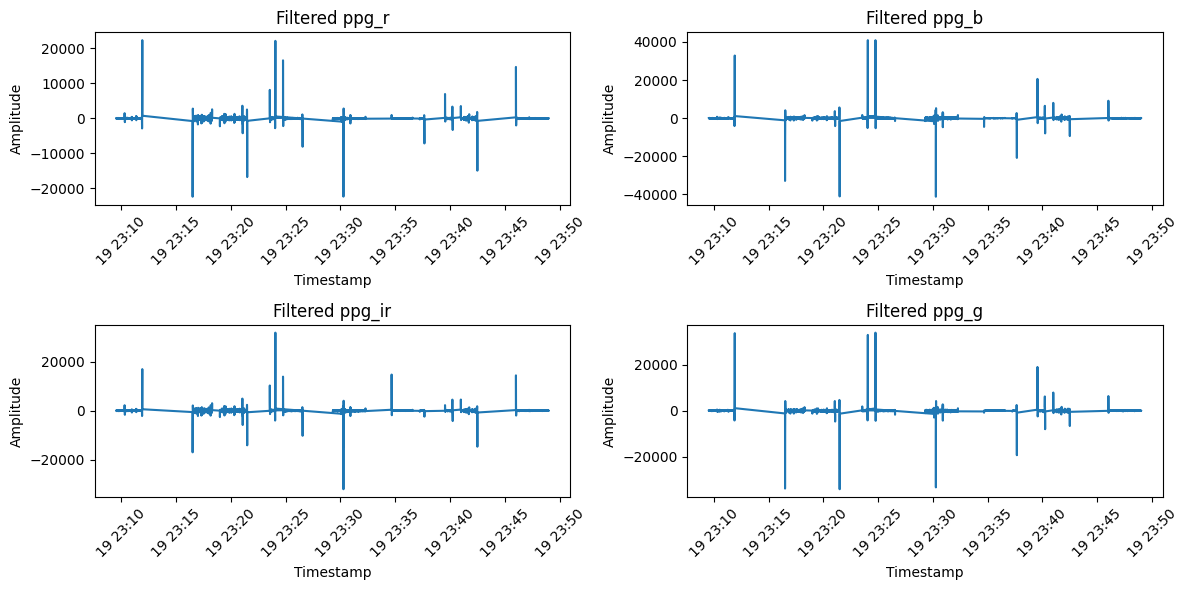

In [7]:
from PPG_PreProcessing import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

# Ensure ppg_data is loaded (you should have loaded it earlier in the script)
# For example:
# ppg_data = pd.read_csv("path/to/your/merged_ppg_data.csv")

# Apply IQR and Bandpass filtering using the functions from PPG_PreProcessing.py
filtered_ppg_data = filter_all(ppg_data, lowcut=0.5, highcut=3)

# Ensure that the filtered dataframe contains the necessary columns
if all(col in filtered_ppg_data.columns for col in ['ppg_r_filtered', 'ppg_b_filtered', 'ppg_ir_filtered', 'ppg_g_filtered']):
    print("All necessary filtered columns are present.")
else:
    print("Missing some filtered columns. Please check the filtering process.")

# 6. Plot ppg_r, ppg_b, ppg_ir, ppg_g columns against timestamps
plt.figure(figsize=(12, 6))

# Plot for ppg_r
plt.subplot(2, 2, 1)
plt.plot(filtered_ppg_data['Timestamp'], filtered_ppg_data['ppg_r_filtered'], label='Filtered ppg_r')
plt.title('Filtered ppg_r')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Plot for ppg_b
plt.subplot(2, 2, 2)
plt.plot(filtered_ppg_data['Timestamp'], filtered_ppg_data['ppg_b_filtered'], label='Filtered ppg_b')
plt.title('Filtered ppg_b')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Plot for ppg_ir
plt.subplot(2, 2, 3)
plt.plot(filtered_ppg_data['Timestamp'], filtered_ppg_data['ppg_ir_filtered'], label='Filtered ppg_ir')
plt.title('Filtered ppg_ir')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Plot for ppg_g
plt.subplot(2, 2, 4)
plt.plot(filtered_ppg_data['Timestamp'], filtered_ppg_data['ppg_g_filtered'], label='Filtered ppg_g')
plt.title('Filtered ppg_g')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


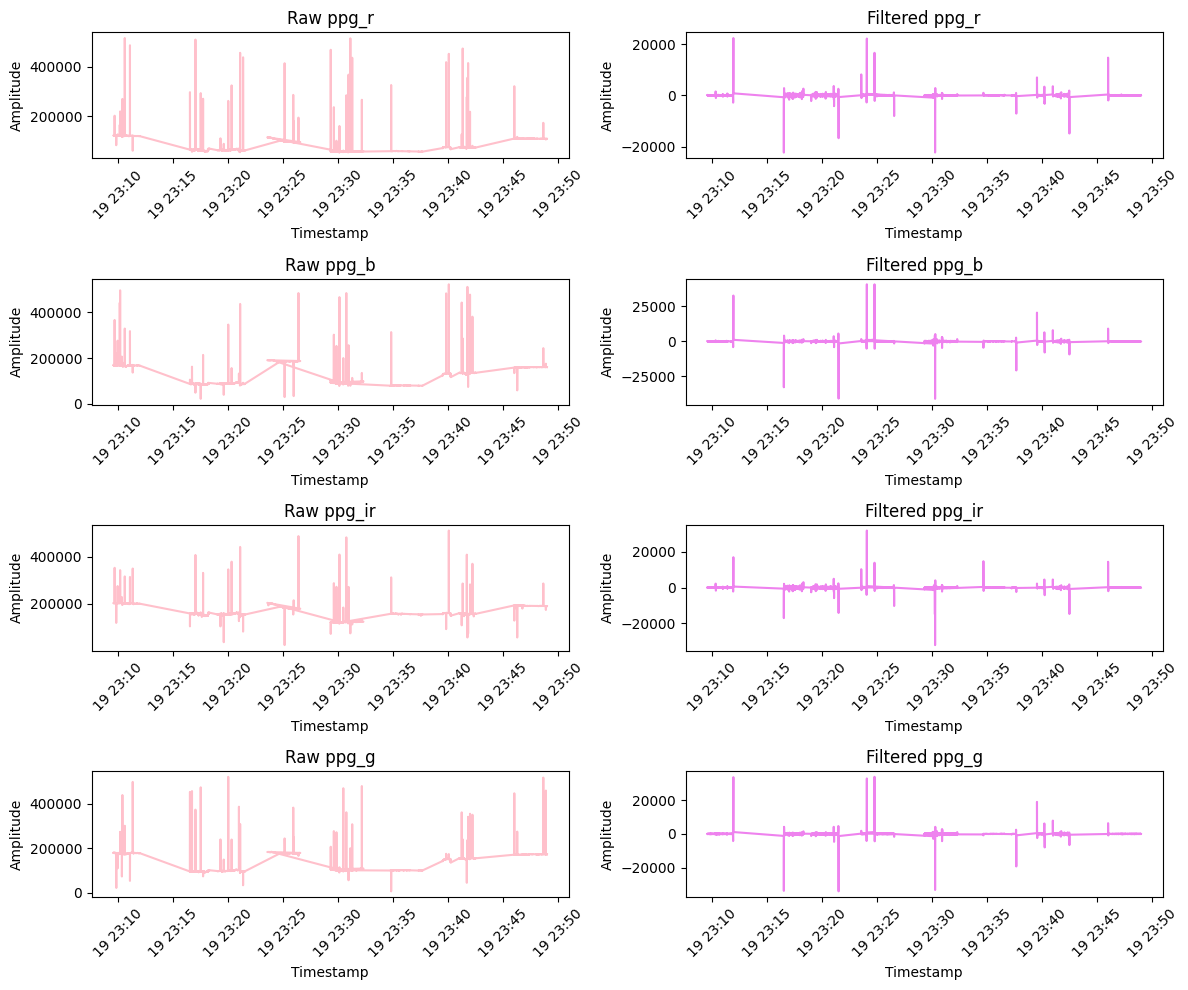

In [8]:
# 6. Plot raw and filtered ppg_r, ppg_b, ppg_ir, ppg_g columns against timestamps
plt.figure(figsize=(12, 10))

# Raw ppg_r
plt.subplot(4, 2, 1)
plt.plot(ppg_data['Timestamp'], ppg_data['ppg_r'], label='Raw ppg_r', color='pink')
plt.title('Raw ppg_r')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Filtered ppg_r
plt.subplot(4, 2, 2)
plt.plot(filtered_ppg_data['Timestamp'], filtered_ppg_data['ppg_r_filtered'], label='Filtered ppg_r', color='violet')
plt.title('Filtered ppg_r')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Raw ppg_b
plt.subplot(4, 2, 3)
plt.plot(ppg_data['Timestamp'], ppg_data['ppg_b'], label='Raw ppg_b', color='pink')
plt.title('Raw ppg_b')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Filtered ppg_b
plt.subplot(4, 2, 4)
plt.plot(filtered_ppg_data['Timestamp'], filtered_ppg_data['ppg_b_filtered'], label='Filtered ppg_b', color='violet')
plt.title('Filtered ppg_b')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Raw ppg_ir
plt.subplot(4, 2, 5)
plt.plot(ppg_data['Timestamp'], ppg_data['ppg_ir'], label='Raw ppg_ir', color='pink')
plt.title('Raw ppg_ir')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Filtered ppg_ir
plt.subplot(4, 2, 6)
plt.plot(filtered_ppg_data['Timestamp'], filtered_ppg_data['ppg_ir_filtered'], label='Filtered ppg_ir', color='violet')
plt.title('Filtered ppg_ir')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Raw ppg_g
plt.subplot(4, 2, 7)
plt.plot(ppg_data['Timestamp'], ppg_data['ppg_g'], label='Raw ppg_g', color='pink')
plt.title('Raw ppg_g')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Filtered ppg_g
plt.subplot(4, 2, 8)
plt.plot(filtered_ppg_data['Timestamp'], filtered_ppg_data['ppg_g_filtered'], label='Filtered ppg_g', color='violet')
plt.title('Filtered ppg_g')
plt.xlabel('Timestamp')
plt.ylabel('Amplitude')
plt.xticks(rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

In [9]:
import pandas as pd
import numpy as np

# 1. Select the necessary columns: "Timestamp" and "O2 Saturation"
ground_truth_data = ground_truth_data[['Timestamp', 'O2 Saturation']]

# 2. Convert "--" values in "O2 Saturation" to NaN
ground_truth_data['O2 Saturation'] = ground_truth_data['O2 Saturation'].replace('--', np.nan)

# 3. Convert the "Timestamp" column to datetime format
ground_truth_data['Timestamp'] = pd.to_datetime(ground_truth_data['Timestamp'], errors='coerce', utc=True)

# 4. Drop rows where "O2 Saturation" is NaN
ground_truth_data = ground_truth_data.dropna(subset=['O2 Saturation'])

# 5. Print the preprocessed dataframe to verify
print(ground_truth_data.head())

                  Timestamp O2 Saturation
0 2024-11-19 23:08:56+00:00            96
1 2024-11-19 23:08:57+00:00            96
2 2024-11-19 23:08:58+00:00            96
3 2024-11-19 23:08:59+00:00            96
4 2024-11-19 23:09:00+00:00            96


In [19]:
import numpy as np
import pandas as pd
import logging
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Ensure the timestamps are properly rounded to the nearest second for both DataFrames
def round_to_second(df):
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Timestamp'] = df['Timestamp'].dt.floor('s')  # Round to the nearest second
    return df

# Calculate R ratio
def calculate_r(df, channel_1, channel_2):
    signal_1 = df[f'ppg_{channel_1}_filtered']
    signal_2 = df[f'ppg_{channel_2}_filtered']
    
    peaks_1, _ = find_peaks(signal_1, height=0, prominence=0.002)
    troughs_1, _ = find_peaks(-signal_1, height=-30000, prominence=0.002)
    
    peaks_2, _ = find_peaks(signal_2, height=0, prominence=0.002)
    troughs_2, _ = find_peaks(-signal_2, height=-30000, prominence=0.002)
    
    ac_1, dc_1 = calculate_ac_dc(signal_1, peaks_1, troughs_1)
    ac_2, dc_2 = calculate_ac_dc(signal_2, peaks_2, troughs_2)
    
    r_ratio = (ac_1 / dc_1) / (ac_2 / dc_2)
    return r_ratio

# AC and DC calculation
def calculate_ac_dc(signal, peaks, troughs):
    dc = np.mean(signal)
    ac = 0
    min_len = min(len(peaks), len(troughs))
    
    if min_len == 0:
        return ac, dc
    
    for i in range(min_len):
        ac += (signal[peaks[i]] - signal[troughs[i]])
    
    ac = ac / min_len
    return ac, dc

# Compute R ratios for different combinations of channels
def compute_r_ratios(df):
    filtered_columns = ['ppg_r_filtered', 'ppg_b_filtered', 'ppg_ir_filtered', 'ppg_g_filtered']
    df = df.dropna(subset=filtered_columns)

    r_red_green = calculate_r(df, 'r', 'g')
    r_green_ir = calculate_r(df, 'g', 'ir')
    r_red_ir = calculate_r(df, 'r', 'ir')
    
    r_ratios_df = pd.DataFrame({
        'Timestamp': df['Timestamp'],
        'red_green_R': r_red_green,
        'green_ir_R': r_green_ir,
        'red_ir_R': r_red_ir
    })
    
    return r_ratios_df

# Resample R ratios to match SpO2 data
def resample_r_ratios(r_ratios_df):
    """
    Resample R ratios to match the frequency of ground truth SpO2 data.
    
    Arguments:
        r_ratios_df (pd.DataFrame): DataFrame containing R ratios for different channels.
        
    Returns:
        pd.DataFrame: Resampled R ratios per second.
    """
    # Round timestamps to the second
    r_ratios_df = round_to_second(r_ratios_df)
    
    # Ensure the data is sorted by timestamp
    r_ratios_df = r_ratios_df.sort_values(by='Timestamp')
    
    # Compute the median R ratios for each second
    r_ratios_resampled = r_ratios_df.groupby('Timestamp').agg({
        'red_green_R': 'median',
        'green_ir_R': 'median',
        'red_ir_R': 'median'
    }).reset_index()
    
    return r_ratios_resampled

# Merge R ratios with ground truth data on 'Timestamp'
def merge_r_ratios_with_ground_truth(r_ratios_resampled, ground_truth_df):
    """
    Merges the resampled R ratios with the ground truth SpO2 data based on the 'Timestamp'.
    
    Arguments:
        r_ratios_resampled (pd.DataFrame): Resampled R ratios DataFrame.
        ground_truth_df (pd.DataFrame): DataFrame containing ground truth SpO2 values.
        
    Returns:
        pd.DataFrame: Merged DataFrame containing both R ratios and SpO2 values.
    """
    # Round the timestamps of ground truth data to match the R ratios' timestamp
    ground_truth_df = round_to_second(ground_truth_df)
    
    # Merge the R ratios with ground truth data based on the 'Timestamp'
    merged_df = pd.merge_asof(ground_truth_df, r_ratios_resampled, on='Timestamp', direction='nearest')
    
    return merged_df

# Example usage
r_ratios_df = compute_r_ratios(filtered_ppg_data)
r_ratios_resampled = resample_r_ratios(r_ratios_df)

# Merge the resampled R ratios with the ground truth data
merged_df = merge_r_ratios_with_ground_truth(r_ratios_resampled, ground_truth_data)

# Display the merged DataFrame
print(merged_df.head())


                  Timestamp O2 Saturation  red_green_R  green_ir_R  red_ir_R
0 2024-11-19 23:08:56+00:00            96     1.591357    0.426051     0.678
1 2024-11-19 23:08:57+00:00            96     1.591357    0.426051     0.678
2 2024-11-19 23:08:58+00:00            96     1.591357    0.426051     0.678
3 2024-11-19 23:08:59+00:00            96     1.591357    0.426051     0.678
4 2024-11-19 23:09:00+00:00            96     1.591357    0.426051     0.678


In [22]:
import numpy as np
import pandas as pd
import logging
from scipy.signal import find_peaks
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import neurokit2 as nk

# Define a function for Lasso Regression to find the k value
def lasso_regression_k(df, channel_1, channel_2, ground_truth='O2 Saturation'):
    # Define the correct column name for the R ratio based on channel combination
    if channel_1 == 'r' and channel_2 == 'g':
        r_column_name = 'red_green_R'
    elif channel_1 == 'g' and channel_2 == 'ir':
        r_column_name = 'green_ir_R'
    elif channel_1 == 'r' and channel_2 == 'ir':
        r_column_name = 'red_ir_R'
    elif channel_1 == 'g' and channel_2 == 'r':  # Added this case
        r_column_name = 'red_green_R'  # Assuming 'red_green_R' is appropriate for this case
    else:
        raise ValueError(f"Unsupported channel combination: {channel_1}, {channel_2}")
    
    # Extract the R ratio values and reshape for model input
    X = np.array(df[r_column_name]).reshape(-1, 1)
    y = df[ground_truth]
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initialize and train the Lasso regression model
    model = Lasso(alpha=0.1)  # Regularization strength (alpha can be adjusted)
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_pred = model.predict(X_test)
    
    # Estimate the calibration coefficient k using the model coefficient
    k_estimated = model.coef_[0]
    
    # Calculate predicted SpO2 values using the k estimation formula
    spo2_pred = 100 * (1 - k_estimated * X_test.flatten())
    
    # Calculate Mean Absolute Error to evaluate model performance
    mae = mean_absolute_error(y_test, spo2_pred)
    
    # Log the results
    logging.info(f"Lasso Regression MAE: {mae}")
    logging.info(f"Estimated k for {channel_1} and {channel_2}: {k_estimated}")
    
    return k_estimated

# Define a function for Ridge Regression to find the k value
def ridge_regression_k(df, channel_1, channel_2, ground_truth='O2 Saturation'):
    # Define the correct column name for the R ratio based on channel combination
    if channel_1 == 'r' and channel_2 == 'g':
        r_column_name = 'red_green_R'
    elif channel_1 == 'g' and channel_2 == 'ir':
        r_column_name = 'green_ir_R'
    elif channel_1 == 'r' and channel_2 == 'ir':
        r_column_name = 'red_ir_R'
    elif channel_1 == 'g' and channel_2 == 'r':  # Added this case
        r_column_name = 'red_green_R'  # Assuming 'red_green_R' is appropriate for this case
    else:
        raise ValueError(f"Unsupported channel combination: {channel_1}, {channel_2}")
    
    # Extract the R ratio values and reshape for model input
    X = np.array(df[r_column_name]).reshape(-1, 1)
    y = df[ground_truth]
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initialize and train the Ridge regression model
    model = Ridge(alpha=1.0)  # Regularization strength (alpha can be adjusted)
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_pred = model.predict(X_test)
    
    # Estimate the calibration coefficient k using the model coefficient
    k_estimated = model.coef_[0]
    
    # Calculate predicted SpO2 values using the k estimation formula
    spo2_pred = 100 * (1 - k_estimated * X_test.flatten())
    
    # Calculate Mean Absolute Error to evaluate model performance
    mae = mean_absolute_error(y_test, spo2_pred)
    
    # Log the results
    logging.info(f"Ridge Regression MAE: {mae}")
    logging.info(f"Estimated k for {channel_1} and {channel_2}: {k_estimated}")
    
    return k_estimated


In [23]:
# Use the correct column names based on the combinations
k_red_ir_lasso = lasso_regression_k(merged_df, 'r', 'ir')
k_green_ir_lasso = lasso_regression_k(merged_df, 'g', 'ir')
k_green_red_lasso = lasso_regression_k(merged_df, 'g', 'r')

k_red_ir_ridge = ridge_regression_k(merged_df, 'r', 'ir')
k_green_ir_ridge = ridge_regression_k(merged_df, 'g', 'ir')
k_green_red_ridge = ridge_regression_k(merged_df, 'g', 'r')


2024-11-22 09:12:35,134 - INFO - Lasso Regression MAE: 2.210727969348659
2024-11-22 09:12:35,135 - INFO - Estimated k for r and ir: 0.0
2024-11-22 09:12:35,140 - INFO - Lasso Regression MAE: 2.210727969348659
2024-11-22 09:12:35,140 - INFO - Estimated k for g and ir: 0.0
2024-11-22 09:12:35,143 - INFO - Lasso Regression MAE: 2.210727969348659
2024-11-22 09:12:35,144 - INFO - Estimated k for g and r: -0.0
2024-11-22 09:12:35,155 - INFO - Ridge Regression MAE: 2.210727969348659
2024-11-22 09:12:35,155 - INFO - Estimated k for r and ir: 0.0
2024-11-22 09:12:35,158 - INFO - Ridge Regression MAE: 2.210727969348659
2024-11-22 09:12:35,158 - INFO - Estimated k for g and ir: 0.0
2024-11-22 09:12:35,161 - INFO - Ridge Regression MAE: 2.210727969348659
2024-11-22 09:12:35,162 - INFO - Estimated k for g and r: -1.3126645462877636e-27


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Example of fitting and visualizing Lasso Regression (similar for Ridge)
def visualize_regression_fit(df, channel_1, channel_2, ground_truth='O2 Saturation'):
    # Define the correct column name for the R ratio
    if channel_1 == 'r' and channel_2 == 'g':
        r_column_name = 'red_green_R'
    elif channel_1 == 'g' and channel_2 == 'ir':
        r_column_name = 'green_ir_R'
    elif channel_1 == 'r' and channel_2 == 'ir':
        r_column_name = 'red_ir_R'
    else:
        raise ValueError(f"Unsupported channel combination: {channel_1}, {channel_2}")

    # Use the correct R ratio column
    X = np.array(df[r_column_name]).reshape(-1, 1)  # Convert to NumPy array and reshape
    y = df[ground_truth]  # Ground truth SpO2 values

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Apply Lasso Regression (or Ridge)
    model = Lasso(alpha=0.1)  # Regularization strength (can also try Ridge)
    model.fit(X_train, y_train)

    # Get predictions
    y_pred = model.predict(X_test)

    # Calculate SpO2 using the formula with the predicted k values
    k_estimated = model.coef_[0]
    spo2_pred = 100 * (1 - k_estimated * X_test.flatten())

    # Mean Absolute Error
    mae = mean_absolute_error(y_test, spo2_pred)
    
    logging.info(f"Lasso Regression MAE: {mae}")
    logging.info(f"Estimated k for {channel_1} and {channel_2}: {k_estimated}")

    # Plotting the results
    plt.figure(figsize=(14, 6))

    # Scatter plot of R ratios vs Ground Truth SpO2 values
    plt.subplot(1, 2, 1)
    plt.scatter(X_test, y_test, color='blue', label='Actual SpO2', alpha=0.6)
    plt.title('R Ratios vs Actual SpO2')
    plt.xlabel(f'{channel_1}-{channel_2} R ratio')
    plt.ylabel('Ground Truth SpO2')
    plt.grid(True)
    
    # Scatter plot of Predicted vs Actual SpO2
    plt.subplot(1, 2, 2)
    plt.scatter(y_test, spo2_pred, color='red', label='Predicted SpO2', alpha=0.6)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--')  # Ideal line
    plt.title('Predicted vs Actual SpO2')
    plt.xlabel('Actual SpO2')
    plt.ylabel('Predicted SpO2')
    plt.grid(True)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

    return k_estimated

# Example usage
k_red_ir_lasso = visualize_regression_fit(merged_df, 'r', 'ir')
k_green_ir_lasso = visualize_regression_fit(merged_df, 'g', 'ir')
k_green_red_lasso = visualize_regression_fit(merged_df, 'g', 'r')
